In [1]:
import os 
import umap 
import numpy as np            
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#config 
results_folder = '/home/rachel/Desktop/mm-vae results/caloric_restriction_DO_mice/cvae_cfc_v1' #'results_mmvae_multiregion_singlegaussianprior'  
dataset_abbrev =  ['Geno', 'Physio'] # ['HC', 'PFC'] 
epoch = 500
latent_dim = 10 # 20 
hues = ['encoder', 'Diet', 'Label'] # ['cell_type', 'strain', 'encoder', '14-6-Bin'] 
random_state = 20

In [3]:
latent_space_1 = pd.read_csv(os.path.join(results_folder, f'latent_variables_epoch{epoch}_vae{dataset_abbrev[0]}.csv'), index_col=False)
latent_space_1

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,Label,Diet,MouseID,encoder
0,-0.110250,-0.058555,-0.328735,1.188853,-1.297177,0.514925,-0.200117,-14.328051,-1.761184,0.156221,0,1D,DO-1D-3001,Geno
1,-1.253298,-0.186359,-0.012972,0.884904,0.439100,0.806514,-0.925121,-15.208837,-3.582314,0.538933,8,1D,DO-1D-3003,Geno
2,-1.462074,-0.200836,-0.318945,0.680194,-0.973010,0.933666,-0.122397,-19.617474,-9.480814,1.028494,3,1D,DO-1D-3010,Geno
3,2.541724,0.157343,0.044539,-0.204639,0.964687,0.553192,0.813101,-17.450350,-1.679430,-1.881747,2,1D,DO-1D-3011,Geno
4,-0.424059,0.095060,-0.228979,-0.833654,0.770806,0.664096,-0.214901,-12.808269,-0.661848,1.317605,0,1D,DO-1D-3013,Geno
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,-0.398112,0.008083,-0.092604,1.426395,1.358565,0.470521,-0.659059,-11.715161,1.021013,0.179694,2,AL,DO-AL-0186,Geno
497,0.367471,-0.090470,-0.053247,0.372529,-1.253722,0.322937,0.217673,-16.104902,-2.683448,-0.286181,1,AL,DO-AL-0188,Geno
498,-0.674276,-0.143692,-0.364083,0.481035,-0.993508,0.609986,0.016790,-13.458200,-2.194456,0.451461,2,AL,DO-AL-0191,Geno
499,-1.195186,0.084252,-0.799142,0.224235,-0.511945,0.762645,0.030592,-16.823717,5.112792,0.742815,3,1D,DO-1D-3083,Geno


In [4]:
latent_space_2 = pd.read_csv(os.path.join(results_folder, f'latent_variables_epoch{epoch}_vae{dataset_abbrev[1]}.csv'), index_col=False)
latent_space_2

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,Label,Diet,MouseID,encoder
0,-0.744869,0.051105,-0.113635,3.179694,-0.188081,0.476167,-0.809492,-14.483226,-0.258668,2.593291,0,1D,DO-1D-3001,Physio
1,-6.514292,-0.015766,-0.146333,-3.609292,0.630414,0.578190,-0.071693,-15.230707,-2.003231,1.562119,8,1D,DO-1D-3003,Physio
2,-3.872760,-0.233145,-0.348144,3.577870,-3.004860,0.880161,0.611071,-19.385021,-0.642420,3.682797,3,1D,DO-1D-3010,Physio
3,-0.211502,-0.223820,-0.170104,7.306596,-3.229039,0.673229,-0.133026,-17.042744,0.168083,2.218666,2,1D,DO-1D-3011,Physio
4,-4.057683,0.068947,-0.198797,3.322991,0.308194,0.398382,-0.146402,-13.047731,-0.244320,1.083357,0,1D,DO-1D-3013,Physio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,-2.768755,-0.047193,-0.031815,0.910576,-2.819979,0.358591,-0.960126,-11.694045,-0.951823,1.616073,2,AL,DO-AL-0186,Physio
497,-1.873416,-0.099994,-0.281759,2.871167,-1.987772,0.646533,0.424681,-15.747652,-0.962144,2.544522,1,AL,DO-AL-0188,Physio
498,-4.979674,0.076707,-0.079161,1.786380,-0.925494,0.355575,-0.017085,-13.446013,-0.825486,4.639005,2,AL,DO-AL-0191,Physio
499,-5.096098,-0.049524,-0.210913,2.748192,-1.608702,0.695584,0.267343,-16.714058,-0.716123,2.191661,3,1D,DO-1D-3083,Physio


In [5]:
latent_space_1.columns = latent_space_1.columns.str.replace(f'_{dataset_abbrev[0]}', '')
latent_space_2.columns = latent_space_2.columns.str.replace(f'_{dataset_abbrev[1]}', '')

In [6]:
latent_space_comb = pd.concat([latent_space_1, latent_space_2])
latent_space_comb = latent_space_comb.reset_index(drop=True)
latent_space_comb

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,Label,Diet,MouseID,encoder
0,-0.110250,-0.058555,-0.328735,1.188853,-1.297177,0.514925,-0.200117,-14.328051,-1.761184,0.156221,0,1D,DO-1D-3001,Geno
1,-1.253298,-0.186359,-0.012972,0.884904,0.439100,0.806514,-0.925121,-15.208837,-3.582314,0.538933,8,1D,DO-1D-3003,Geno
2,-1.462074,-0.200836,-0.318945,0.680194,-0.973010,0.933666,-0.122397,-19.617474,-9.480814,1.028494,3,1D,DO-1D-3010,Geno
3,2.541724,0.157343,0.044539,-0.204639,0.964687,0.553192,0.813101,-17.450350,-1.679430,-1.881747,2,1D,DO-1D-3011,Geno
4,-0.424059,0.095060,-0.228979,-0.833654,0.770806,0.664096,-0.214901,-12.808269,-0.661848,1.317605,0,1D,DO-1D-3013,Geno
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,-2.768755,-0.047193,-0.031815,0.910576,-2.819979,0.358591,-0.960126,-11.694045,-0.951823,1.616073,2,AL,DO-AL-0186,Physio
998,-1.873416,-0.099994,-0.281759,2.871167,-1.987772,0.646533,0.424681,-15.747652,-0.962144,2.544522,1,AL,DO-AL-0188,Physio
999,-4.979674,0.076707,-0.079161,1.786380,-0.925494,0.355575,-0.017085,-13.446013,-0.825486,4.639005,2,AL,DO-AL-0191,Physio
1000,-5.096098,-0.049524,-0.210913,2.748192,-1.608702,0.695584,0.267343,-16.714058,-0.716123,2.191661,3,1D,DO-1D-3083,Physio


<Axes: xlabel='LV1', ylabel='Density'>

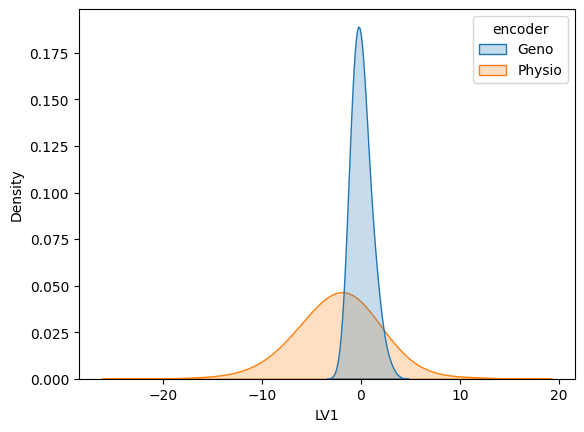

In [7]:
sns.kdeplot(data=latent_space_comb[['LV1', 'encoder']], x='LV1', hue='encoder', fill=True, bw_adjust=2)

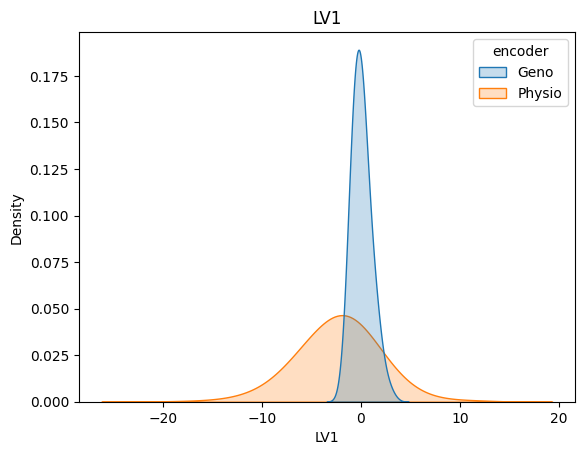

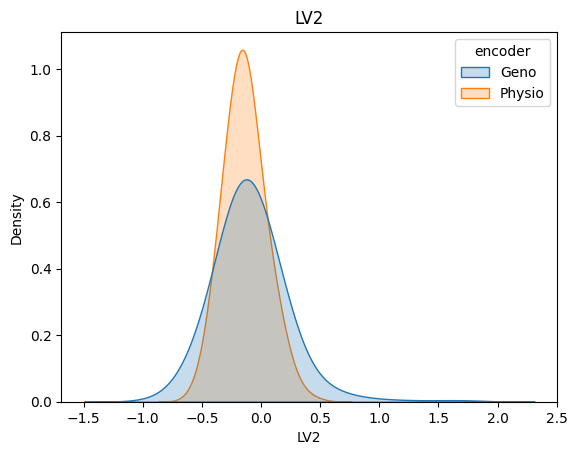

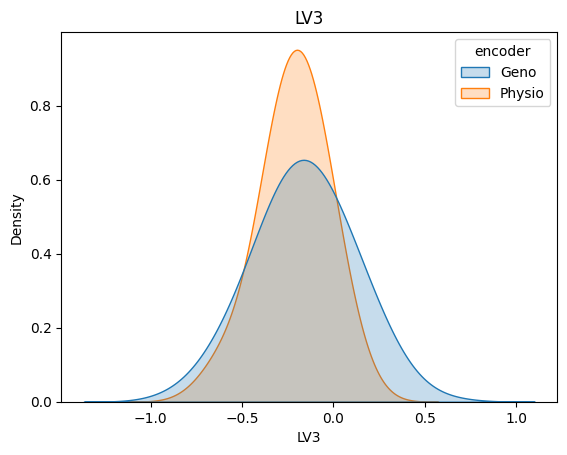

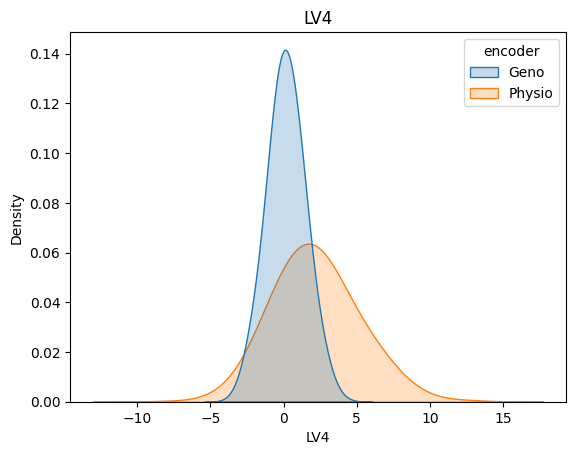

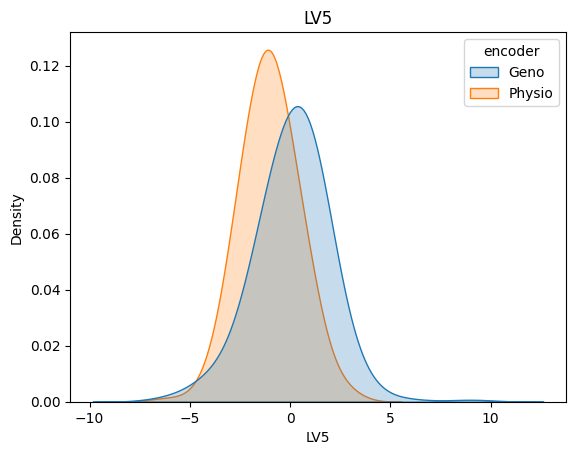

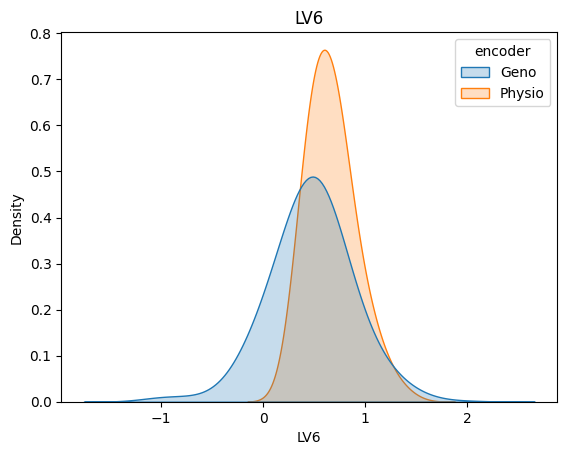

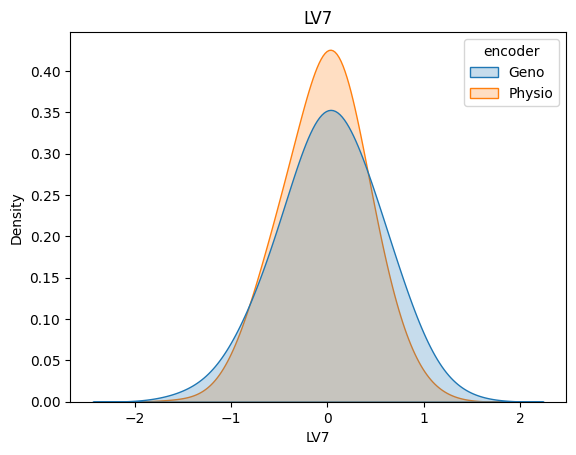

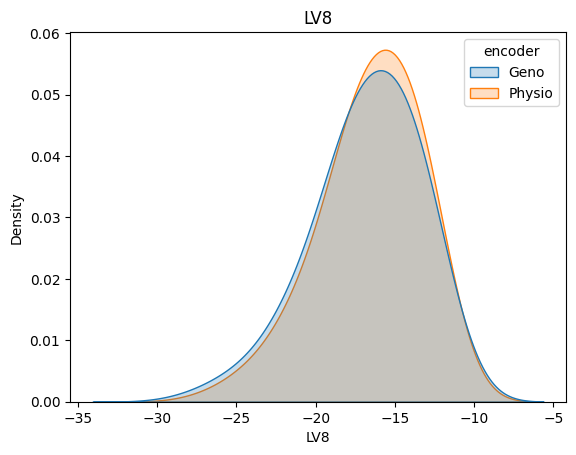

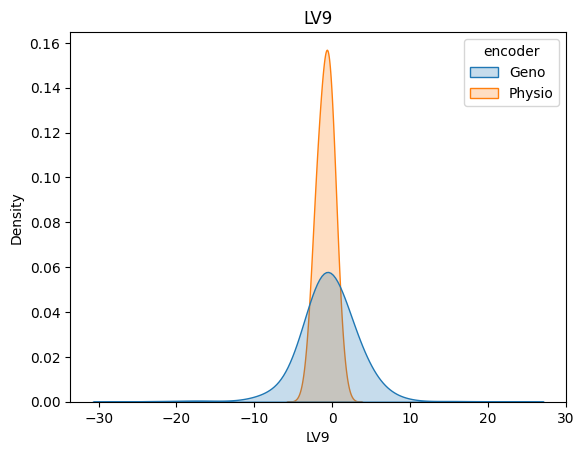

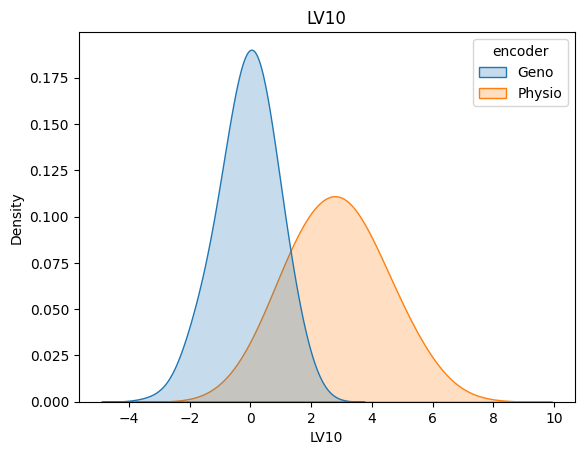

In [8]:
for column in latent_space_comb.columns[:latent_dim]:
    plt.figure()
    sns.kdeplot(data=latent_space_comb[[column, 'encoder']], x=column, hue='encoder', fill=True, bw_adjust=2)
    plt.title(column)

In [9]:
latent_space_sub = latent_space_comb.iloc[:, :latent_dim]

In [10]:
latent_space_sub

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10
0,-0.110250,-0.058555,-0.328735,1.188853,-1.297177,0.514925,-0.200117,-14.328051,-1.761184,0.156221
1,-1.253298,-0.186359,-0.012972,0.884904,0.439100,0.806514,-0.925121,-15.208837,-3.582314,0.538933
2,-1.462074,-0.200836,-0.318945,0.680194,-0.973010,0.933666,-0.122397,-19.617474,-9.480814,1.028494
3,2.541724,0.157343,0.044539,-0.204639,0.964687,0.553192,0.813101,-17.450350,-1.679430,-1.881747
4,-0.424059,0.095060,-0.228979,-0.833654,0.770806,0.664096,-0.214901,-12.808269,-0.661848,1.317605
...,...,...,...,...,...,...,...,...,...,...
997,-2.768755,-0.047193,-0.031815,0.910576,-2.819979,0.358591,-0.960126,-11.694045,-0.951823,1.616073
998,-1.873416,-0.099994,-0.281759,2.871167,-1.987772,0.646533,0.424681,-15.747652,-0.962144,2.544522
999,-4.979674,0.076707,-0.079161,1.786380,-0.925494,0.355575,-0.017085,-13.446013,-0.825486,4.639005
1000,-5.096098,-0.049524,-0.210913,2.748192,-1.608702,0.695584,0.267343,-16.714058,-0.716123,2.191661


In [11]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_state)
embedding = reducer.fit_transform(latent_space_sub)

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]

In [13]:
embedding_df

,UMAP1,UMAP2,encoder,Diet,Label
0,81.044815,147.390884,Geno,1D,0
1,82.538666,147.608932,Geno,1D,8
2,85.414406,147.269684,Geno,1D,3
3,83.336090,145.144913,Geno,1D,2
4,78.462975,146.159576,Geno,1D,0
...,...,...,...,...,...
997,79.230980,151.298462,Physio,AL,2
998,83.351921,151.058380,Physio,AL,1
999,81.660385,152.722473,Physio,AL,2
1000,83.808868,153.704269,Physio,1D,3


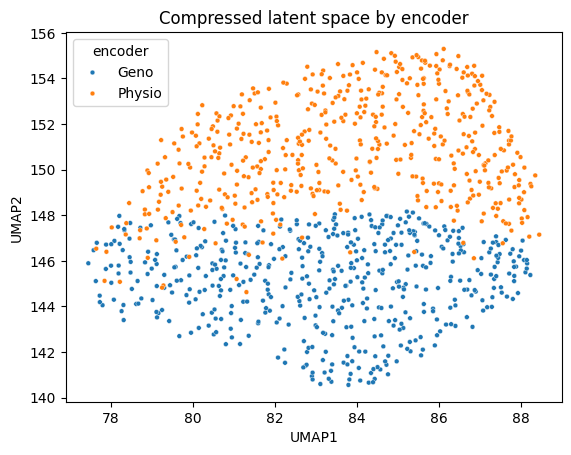

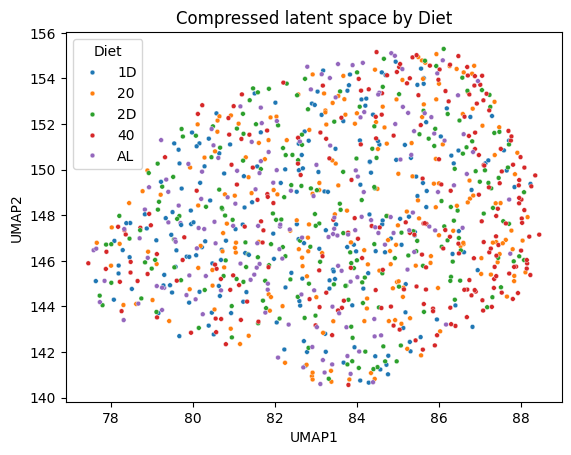

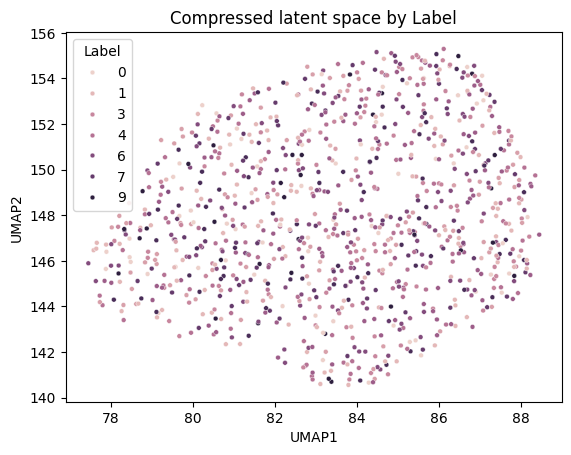

In [14]:
for hue in hues: 
    plt.figure()
    sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    plt.title(f'Compressed latent space by {hue}')

In [15]:
embedding_df.to_csv(os.path.join(results_folder, 'latent_umap_embeddings.csv'))